In [1]:
%matplotlib widget
import scipy
import numpy as np
import matplotlib.pyplot as plt
import symengine
from astropy import units as u
from astropy import constants as const
import pandas as pd
from astropy.units import Quantity
from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d import Axes3D 
import mpl_toolkits.mplot3d as m3d
from math import lgamma, log, exp, comb
from SolverFunction import _find_unknown,auto_bracket,solve_quantity, simplify
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7a3f9436de80>

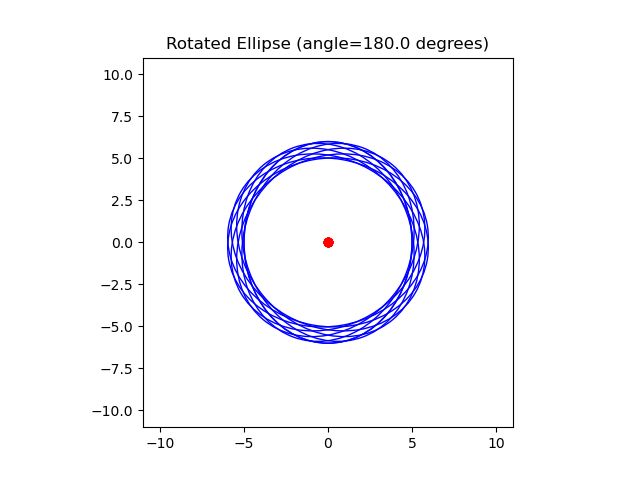

In [2]:
from matplotlib.patches import Ellipse
b=10
n=1.2
# --- Plotting ---
fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'}) # Ensure equal aspect ratio
for angle in np.linspace(0,180,10):
    # --- Ellipse Parameters ---
    center_x = 0
    center_y = 0
    width = b  # Corresponds to major/minor axis depending on rotation
    height = b*n
    angle_degrees = angle # Anti-clockwise rotation in degrees


    # Create the Ellipse patch
    ellipse = Ellipse(
        xy=(center_x, center_y),
        width=width,
        height=height,
        angle=angle_degrees,
        facecolor='none',  # No fill
        edgecolor='b'       # Blue edge color
    )

    # Add the ellipse to the plot
    ax.add_patch(ellipse)

    # Add a marker at the center for reference
    ax.plot(center_x, center_y, 'ro')

    # Set axis limits to visualize the full ellipse

ax.set_xlim(center_x - max(width, height) / 2 - 5, center_x + max(width, height) / 2 + 5)
ax.set_ylim(center_y - max(width, height) / 2 - 5, center_y + max(width, height) / 2 + 5)

ax.set_title(f'Rotated Ellipse (angle={angle_degrees} degrees)')
#plt.grid(True)
plt.show()


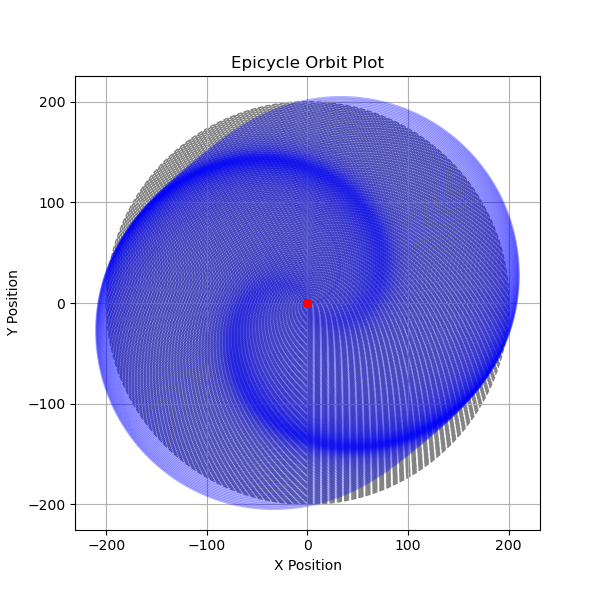

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_title('Epicycle Orbit Plot')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.grid(True)

N = 200
factor = 1.1
for r in np.linspace(1, N, N+1):
    # --- Parameters ---
    R_major = r  # Radius of the deferent (major circle)
    r_minor = R_major / 10  # Radius of the epicycle (minor circle)
    omega_major = 1  # Angular velocity of the major circle
    omega_minor = 2  # Angular velocity of the minor circle

    # Angular rotation of the full orbit, scaling with r.
    angle = r * factor  # degrees
    theta = np.radians(angle)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    # Time array
    t = np.linspace(0, 2 * np.pi, 1000)

    # Unrotated epicycle orbit
    x_base = R_major * np.cos(omega_major * t) + r_minor * np.cos((omega_major + omega_minor) * t)
    y_base = R_major * np.sin(omega_major * t) + r_minor * np.sin((omega_major + omega_minor) * t)

    # Rotate the orbit by theta
    x = x_base * cos_theta - y_base * sin_theta
    y = x_base * sin_theta + y_base * cos_theta

    # Plot the orbit path for this radius
    ax.plot(x, y, 'b',alpha=0.3)

    # Plot the central point (e.g., Earth in historical models)
    ax.plot(0, 0, 'ro', markersize=5)

    # Add circles to illustrate the deferent (rotation does not change a circle)
    deferent = plt.Circle((0, 0), R_major, color='gray', fill=False, linestyle='--')
    ax.add_patch(deferent)

plt.show()

In [4]:
# animate a star in a rigidly precessing orbit (moving dot in 3D)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Stop previous animations just so we don't overload your notebook.
try:
    ani.event_source.stop()
except Exception:
    pass

precessionrate = 0.4  # degrees per frame
N = 3000
a = 5   # Semi-major axis
b = 10  # Semi-minor axis
z_amp = 1.0     # Amplitude of z oscillation
z_freq = 0.015   # Frequency factor for z oscillation

# Time array and angles
t = np.linspace(0, N, N + 1)
phi = t
theta = np.radians(precessionrate * t)
cos_theta = np.cos(theta)
sin_theta = np.sin(theta)

# Position of one moving point on a precessing ellipse
x_base = a * np.cos(phi)
y_base = b * np.sin(phi)
x = x_base * cos_theta - y_base * sin_theta
y = x_base * sin_theta + y_base * cos_theta

# Sinusoidal z component
z = z_amp * np.sin(z_freq * t)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Moving Dot on a Precessing 3D Orbit')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_xlim(-b - 1, b + 1)
ax.set_ylim(-b - 1, b + 1)
ax.set_zlim(-z_amp - 1, z_amp + 1)
ax.grid(True)

# Marker only (no trailing line)
point, = ax.plot([x[0]], [y[0]], [z[0]], 'bo', markersize=7)
line, = ax.plot([], [], [], 'b-', alpha=0.5)  # Optional: trailing line for the orbit path

def init():
    point.set_data([x[0]], [y[0]])
    point.set_3d_properties([z[0]])
    line.set_data([], [])
    line.set_3d_properties([])
    return point, line

def animate(i):
    point.set_data([x[i]], [y[i]])
    point.set_3d_properties([z[i]])
    line.set_data(x[:i], y[:i])
    line.set_3d_properties(z[:i])
    return point, line
plt.rcParams['animation.embed_limit'] = 2**128
ani = animation.FuncAnimation(
    fig, animate, init_func=init, frames=N + 1, interval=16.67, blit=True
)
plt.close(fig)
HTML(ani.to_jshtml())

KeyboardInterrupt: 

In [38]:
# animate a rigidly precessing orbit traced over time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Stop previous animations so multiple timers do not overlap.
try:
    ani_trace.event_source.stop()
except Exception:
    pass

precessionrate = 0.4  # degrees per frame
N = 30
a = 5   # Semi-major axis
b = 10  # Semi-minor axis

# Parameter around each ellipse and frame angles.
u = np.linspace(0, 2 * np.pi, 240)
theta_frames = np.radians(precessionrate * np.arange(N + 1))

def ellipse_at_theta(theta):
    x = a * np.cos(u) * np.cos(theta) - b * np.sin(u) * np.sin(theta)
    y = a * np.cos(u) * np.sin(theta) + b * np.sin(u) * np.cos(theta)
    return x, y

# Precompute all frame points and flatten into one traced path.
x_frames = []
y_frames = []
for th in theta_frames:
    x_i, y_i = ellipse_at_theta(th)
    x_frames.append(x_i)
    y_frames.append(y_i)

x_path = np.concatenate(x_frames)
y_path = np.concatenate(y_frames)

fig, ax = plt.subplots(figsize=(6, 6))
line, = ax.plot([], [], 'b-', lw=1.5)
ax.set_title('Precessing Orbit Traced Over Time')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.grid()
ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_aspect('equal')

pts_per_frame = len(u)

def init():
    line.set_data(x_path[:1], y_path[:1])
    return line,

def animate(i):
    end = (i + 1) * pts_per_frame
    line.set_data(x_path[:end], y_path[:end])
    return line,

ani_trace = animation.FuncAnimation(
    fig, animate, init_func=init, frames=N + 1, interval=16.67, blit=True
 )
plt.close(fig)
HTML(ani_trace.to_jshtml())


In [3]:
# animate a rigidly precessing orbit (fixed size, changing orientation only)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Stop previous animations just so we don't overload your notebook.
try:
    ani.event_source.stop()
except Exception:
    pass

precessionrate = 0.1  # degrees per frame
N = 300
a = 5   # Semi-major axis
b = 10  # Semi-minor axis

# Parameter around the ellipse.
u = np.linspace(0, 2 * np.pi, 600)

# Precession angle for each animation frame.
theta_frames = np.radians(precessionrate * np.arange(N + 1))

def ellipse_at_theta(theta):
    x = a * np.cos(u) * np.cos(theta) - b * np.sin(u) * np.sin(theta)
    y = a * np.cos(u) * np.sin(theta) + b * np.sin(u) * np.cos(theta)
    return x, y

fig, ax = plt.subplots(figsize=(6, 6))
x_init, y_init = ellipse_at_theta(theta_frames[0])
line, = ax.plot(x_init, y_init, 'b-', lw=2)
ax.set_title('Precessing Orbit of a Star')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.grid()
ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_aspect('equal')

def init():
    line.set_data(x_init, y_init)
    return line,

def animate(i):
    x, y = ellipse_at_theta(theta_frames[i])
    line.set_data(x, y)
    return line,

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=N + 1, interval=16.67, blit=True)
plt.close(fig)  # Prevent duplicate static display and keep HTML animation output
HTML(ani.to_jshtml())


KeyboardInterrupt: 

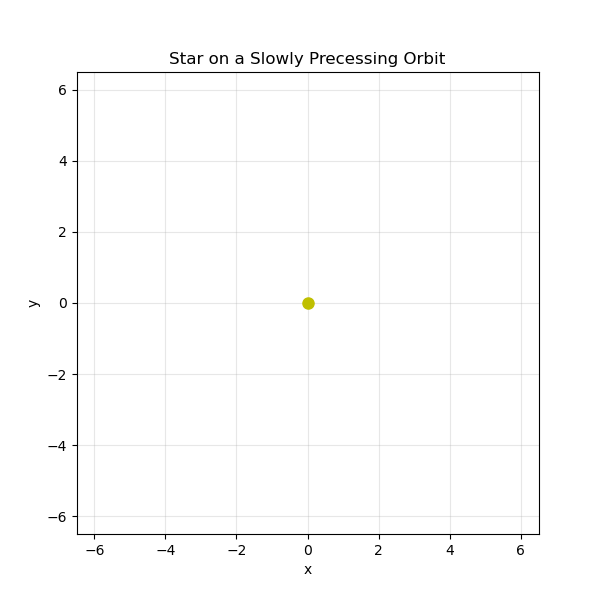

In [12]:
# 2D animation: star (single dot) moving on a slowly precessing orbit, with traced path

# Stop older animation timer if this cell is re-run
plt.close(fig2)
try:
    ani_star_precess.event_source.stop()
except Exception:
    pass

# Parameters
N_frames = 1500
a_orbit = 5.0          # semi-major axis
b_orbit = 2.0          # semi-minor axis
omega_orbit = 0.01     # orbital angular speed (rad/frame)
omega_prec = 0.005     # apsidal precession speed (rad/frame)

k = np.arange(N_frames + 1)
phi_orbit = omega_orbit * k
theta_prec = omega_prec * k

# Position of moving star on a precessing ellipse
x_star = a_orbit * np.cos(phi_orbit) * np.cos(theta_prec) - b_orbit * np.sin(phi_orbit) * np.sin(theta_prec)
y_star = a_orbit * np.cos(phi_orbit) * np.sin(theta_prec) + b_orbit * np.sin(phi_orbit) * np.cos(theta_prec)

# Figure setup
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.set_aspect("equal")
ax2.set_xlim(-6.5, 6.5)
ax2.set_ylim(-6.5, 6.5)
ax2.set_title("Star on a Slowly Precessing Orbit")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.grid(True, alpha=0.3)
ax2.plot(0, 0, "yo", ms=8)  # central mass at origin

# Artists: traced path + star dot
trace_line, = ax2.plot([], [], "b-", lw=1.5, alpha=0.9)
star_dot, = ax2.plot([], [], "wo", ms=6, markeredgecolor="k")

def init():
    trace_line.set_data([], [])
    star_dot.set_data([], [])
    return trace_line, star_dot

def update(i):
    trace_line.set_data(x_star[:i+1], y_star[:i+1])
    star_dot.set_data([x_star[i]], [y_star[i]])
    return trace_line, star_dot

ani_star_precess = animation.FuncAnimation(
    fig2, update, init_func=init, frames=N_frames + 1, interval=20, blit=True
)

#plt.close(fig2)
#HTML(ani_star_precess.to_jshtml())

NameError: name 'animation' is not defined

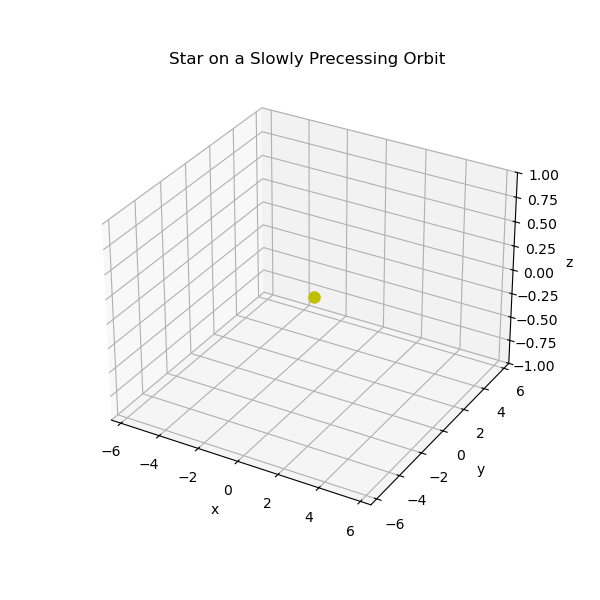

In [2]:
# 2D animation: star (single dot) moving on a slowly precessing orbit, with traced path

# Stop older animation timer if this cell is re-run
try:
    ani_star_precess.event_source.stop()
except Exception:
    pass

# Parameters
N_frames = 1000
a_orbit = 5.0          # semi-major axis
b_orbit = 3.0          # semi-minor axis
omega_orbit = 0.10     # orbital angular speed (rad/frame)
omega_prec = 0.003     # apsidal precession speed (rad/frame)

k = np.arange(N_frames + 1)
phi_orbit = omega_orbit * k
theta_prec = omega_prec * k

# Position of moving star on a precessing ellipse
x_star = a_orbit * np.cos(phi_orbit) * np.cos(theta_prec) - b_orbit * np.sin(phi_orbit) * np.sin(theta_prec)
y_star = a_orbit * np.cos(phi_orbit) * np.sin(theta_prec) + b_orbit * np.sin(phi_orbit) * np.cos(theta_prec)
z_star = 0.1 * np.sin(0.02 * k)  # Optional: add small vertical oscillation for visual interest

# Make a 3d plot with the same x,y but also z for a bit of depth (even though it's not a true 3D orbit)

# Figure setup
fig2 = plt.figure(figsize=(6, 6))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.set_xlim(-6.5, 6.5)
ax2.set_ylim(-6.5, 6.5)
ax2.set_zlim(-1, 1)
ax2.set_title("Star on a Slowly Precessing Orbit")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.grid(True, alpha=0.3)
ax2.plot(0, 0, 0, "yo", ms=8)  # central mass at origin

# Artists: traced path + star dot
trace_line, = ax2.plot([], [], [], "b-", lw=1.5, alpha=0.9)
star_dot, = ax2.plot([], [], [], "wo", ms=6, markeredgecolor="k")

def init():
    trace_line.set_data([], [])
    trace_line.set_3d_properties([])
    star_dot.set_data([], [])
    star_dot.set_3d_properties([])
    return trace_line, star_dot

def update(i):
    trace_line.set_data(x_star[:i+1], y_star[:i+1])
    trace_line.set_3d_properties(z_star[:i+1])
    star_dot.set_data([x_star[i]], [y_star[i]])
    star_dot.set_3d_properties([z_star[i]])
    return trace_line, star_dot

ani_star_precess = animation.FuncAnimation(
    fig2, update, init_func=init, frames=N_frames + 1, interval=20, blit=True
)